In [2]:
import os, sys
from google.colab import drive
drive.mount('/content/drive')
os.chdir("/content/drive/My Drive/Colab Notebooks")
sys.path.append("/content/drive/My Drive/Colab Notebooks")

Mounted at /content/drive


In [11]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [4]:

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/salary_experience_dataset.csv")

In [5]:
X = df[["Experience_Years"]]
y = df["Salary"]


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
degree = 3
poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X_train.values)

In [15]:

model = LinearRegression()
model.fit(X_poly, y_train)

LinearRegression()

In [17]:
X_test_poly = poly.transform(X_test)
y_pred = model.predict(X_test_poly)

print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R2 Score: 1.0
Mean Squared Error: 2.060153534311909e-18


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


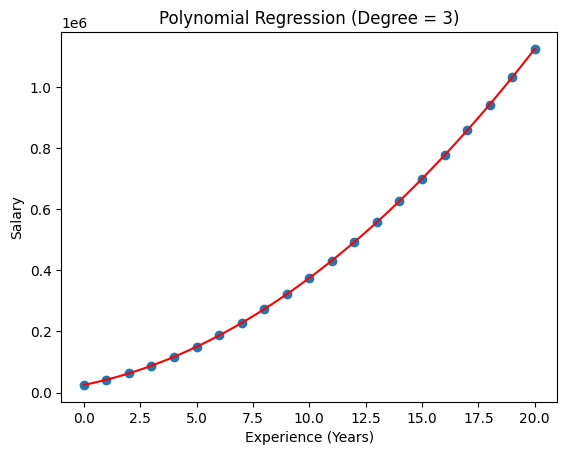

In [25]:
X_grid = np.linspace(X['Experience_Years'].min(), X['Experience_Years'].max(), 100)
X_grid = X_grid.reshape(-1, 1)

X_grid_poly = poly.transform(X_grid)
y_grid_pred = model.predict(X_grid_poly)

plt.scatter(X, y)
plt.plot(X_grid, y_grid_pred, color='red')

plt.title("Polynomial Regression (Degree = {})".format(degree))
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")
plt.show()